In [3]:
# Capstone 2: NYC Rental Price Data Wrangling
#Project Goal:** The objective of this notebook is to clean and prepare the NYC rental dataset. I will perform data collection, definition, and cleaning to ensure the data is reliable for analyzing the key drivers of rental prices in New York City.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('ggplot')
%matplotlib inline

In [5]:
file_name = 'NY Realstate Pricing.xlsx'
df = pd.read_excel(file_name)

print(f"Successfully loaded {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

Successfully loaded 17614 rows and 12 columns.


,F1,id,neighbourhood,latitude,longitude,room_type,price,days_occupied_in_2019,minimum_nights,number_of_reviews,reviews_per_month,availability_2020
0,0,2595,Midtown,40.75362,-73.98377,Entire home/apt,225,15,10,48,0.39,1
1,1,3831,Brooklyn,40.68514,-73.95976,Entire home/apt,89,188,1,295,4.67,1
2,2,5099,Manhattan,40.74767,-73.97500,Entire home/apt,200,362,3,78,0.60,19
3,3,5121,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,0,29,49,0.38,365
4,4,5178,Manhattan,40.76489,-73.98493,Private room,79,141,2,454,3.52,242


In [6]:
## Data Definition
#In this step, I will examine the data types, column names, and summary statistics to identify any initial issues such as missing values or logical errors.

In [7]:
print("--- Data Info ---")
df.info()

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17614 entries, 0 to 17613
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   F1                     17614 non-null  int64  
 1   id                     17614 non-null  int64  
 2   neighbourhood          17614 non-null  object 
 3   latitude               17614 non-null  float64
 4   longitude              17614 non-null  float64
 5   room_type              17614 non-null  object 
 6   price                  17614 non-null  int64  
 7   days_occupied_in_2019  17614 non-null  int64  
 8   minimum_nights         17614 non-null  int64  
 9   number_of_reviews      17614 non-null  int64  
 10  reviews_per_month      17614 non-null  float64
 11  availability_2020      17614 non-null  int64  
dtypes: float64(3), int64(7), object(2)
memory usage: 1.6+ MB


In [8]:
print("\n--- Summary Statistics ---")
summary = df.describe().T
summary['range'] = summary['max'] - summary['min']
display(summary)


--- Summary Statistics ---


,count,mean,std,min,25%,50%,75%,max,range
F1,17614.0,1.854756e+04,1.100072e+04,0.00000,8.192250e+03,1.949650e+04,2.868675e+04,3.559600e+04,3.559600e+04
id,17614.0,1.572032e+07,9.644155e+06,2595.00000,6.718288e+06,1.654699e+07,2.407707e+07,3.056528e+07,3.056269e+07
latitude,17614.0,4.072675e+01,5.698110e-02,40.50868,4.068604e+01,4.072054e+01,4.076313e+01,4.090804e+01,3.993600e-01
longitude,17614.0,-7.394773e+01,5.021280e-02,-74.23986,-7.398094e+01,-7.395305e+01,-7.393068e+01,-7.372179e+01,5.180700e-01
price,17614.0,1.454555e+02,1.949907e+02,0.00000,7.000000e+01,1.090000e+02,1.700000e+02,9.999000e+03,9.999000e+03
days_occupied_in_2019,17614.0,1.795177e+02,1.302020e+02,0.00000,3.500000e+01,1.980000e+02,3.010000e+02,3.640000e+02,3.640000e+02
minimum_nights,17614.0,7.392926e+00,1.923387e+01,1.00000,2.000000e+00,3.000000e+00,5.000000e+00,1.125000e+03,1.124000e+03
number_of_reviews,17614.0,5.612899e+01,6.597237e+01,1.00000,9.000000e+00,3.300000e+01,7.900000e+01,6.750000e+02,6.740000e+02
reviews_per_month,17614.0,1.607060e+00,1.635528e+00,0.01000,3.400000e-01,1.060000e+00,2.460000e+00,1.925000e+01,1.924000e+01
availability_2020,17614.0,1.541548e+02,1.380797e+02,0.00000,8.000000e+00,1.250000e+02,3.090000e+02,3.650000e+02,3.650000e+02


In [12]:
print("\n--- Categorical Analysis ---")
print(f"Neighbourhoods count: {df['neighbourhood'].nunique()}")
print(f"Room types available: {df['room_type'].unique()}")


--- Categorical Analysis ---
Neighbourhoods count: 186
Room types available: ['Entire home/apt' 'Private room' 'Shared room' 'Hotel room']


In [10]:
duplicates = df.duplicated(subset=['id']).sum()
print(f"\nNumber of duplicate listing IDs: {duplicates}")


Number of duplicate listing IDs: 0


In [14]:
## Data Cleaning
# Based on the initial inspection, I will perform the following cleaning steps:
#1. **Drop Redundant Columns**: Remove 'F1' as it is just an index from the source file.
#2. **Handle Inconsistent Data**: Check for $0 prices or unrealistic minimum nights.
#3. **Handle Missing Values**: Although the initial check showed no nulls, I will re-verify.

In [15]:
if 'F1' in df.columns:
    df.drop(columns=['F1'], inplace=True)
    print("Column 'F1' dropped.")

Column 'F1' dropped.


In [16]:
zero_prices = df[df['price'] == 0]
print(f"Records with price $0: {len(zero_prices)}")

Records with price $0: 7


In [17]:
if len(zero_prices) > 0:
    df = df[df['price'] > 0]
    print("Zero-price records removed.")

Zero-price records removed.


In [18]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
id                       0
neighbourhood            0
latitude                 0
longitude                0
room_type                0
price                    0
days_occupied_in_2019    0
minimum_nights           0
number_of_reviews        0
reviews_per_month        0
availability_2020        0
dtype: int64


In [19]:
df.to_csv('NYC_Rental_Cleaned.csv', index=False)
print("\nData Wrangling stage complete. Final shape:", df.shape)


Data Wrangling stage complete. Final shape: (17607, 11)


In [20]:
df_test = pd.read_csv('NYC_Rental_Cleaned.csv')
print(f"Verified rows: {len(df_test)}")
display(df_test.head())

Verified rows: 17607


,id,neighbourhood,latitude,longitude,room_type,price,days_occupied_in_2019,minimum_nights,number_of_reviews,reviews_per_month,availability_2020
0,2595,Midtown,40.75362,-73.98377,Entire home/apt,225,15,10,48,0.39,1
1,3831,Brooklyn,40.68514,-73.95976,Entire home/apt,89,188,1,295,4.67,1
2,5099,Manhattan,40.74767,-73.97500,Entire home/apt,200,362,3,78,0.60,19
3,5121,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,0,29,49,0.38,365
4,5178,Manhattan,40.76489,-73.98493,Private room,79,141,2,454,3.52,242


In [23]:
## Data Wrangling Summary
#In this initial stage, I successfully:
#1. **Identified Data Issues**: Found that the 'F1' column was a redundant index and identified $0 price entries as data errors.
#2. **Cleaned Data**: Dropped irrelevant columns and filtered out invalid price records.
#3. **Data Integrity**: Confirmed that each 'id' is unique and there are no missing values across the 17,000+ records.
#4. **Output**: Saved the clean dataset as `NYC_Rental_Cleaned.csv` for the upcoming Exploratory Data Analysis (EDA) phase.

#Next Step**: Will focus on EDA to visualize price distributions across different NYC neighborhoods and room types.

In [24]:
# Cell 1: Load Libraries and Clean Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
plt.style.use('ggplot')
%matplotlib inline
sns.set_theme(style="whitegrid")

# Load your cleaned data
df = pd.read_csv('NYC_Rental_Cleaned.csv')

# Quick profile check
print(f"Dataset Shape: {df.shape}")
df.info()

Dataset Shape: (17607, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17607 entries, 0 to 17606
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     17607 non-null  int64  
 1   neighbourhood          17607 non-null  object 
 2   latitude               17607 non-null  float64
 3   longitude              17607 non-null  float64
 4   room_type              17607 non-null  object 
 5   price                  17607 non-null  int64  
 6   days_occupied_in_2019  17607 non-null  int64  
 7   minimum_nights         17607 non-null  int64  
 8   number_of_reviews      17607 non-null  int64  
 9   reviews_per_month      17607 non-null  float64
 10  availability_2020      17607 non-null  int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 1.5+ MB


In [26]:
# Cell 2: Descriptive Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,17607.0,1.571840e+07,9.645577e+06,2595.00000,6.717298e+06,1.654447e+07,2.407886e+07,3.056528e+07
latitude,17607.0,4.072677e+01,5.698743e-02,40.50868,4.068605e+01,4.072057e+01,4.076313e+01,4.090804e+01
longitude,17607.0,-7.394774e+01,5.021888e-02,-74.23986,-7.398095e+01,-7.395305e+01,-7.393070e+01,-7.372179e+01
price,17607.0,1.455133e+02,1.950079e+02,10.00000,7.000000e+01,1.090000e+02,1.710000e+02,9.999000e+03
days_occupied_in_2019,17607.0,1.795344e+02,1.302143e+02,0.00000,3.500000e+01,1.980000e+02,3.010000e+02,3.640000e+02
minimum_nights,17607.0,7.391890e+00,1.923596e+01,1.00000,2.000000e+00,3.000000e+00,5.000000e+00,1.125000e+03
number_of_reviews,17607.0,5.613018e+01,6.597552e+01,1.00000,9.000000e+00,3.300000e+01,7.900000e+01,6.750000e+02
reviews_per_month,17607.0,1.606906e+00,1.635280e+00,0.01000,3.400000e-01,1.060000e+00,2.460000e+00,1.925000e+01
availability_2020,17607.0,1.541259e+02,1.380793e+02,0.00000,8.000000e+00,1.250000e+02,3.090000e+02,3.650000e+02


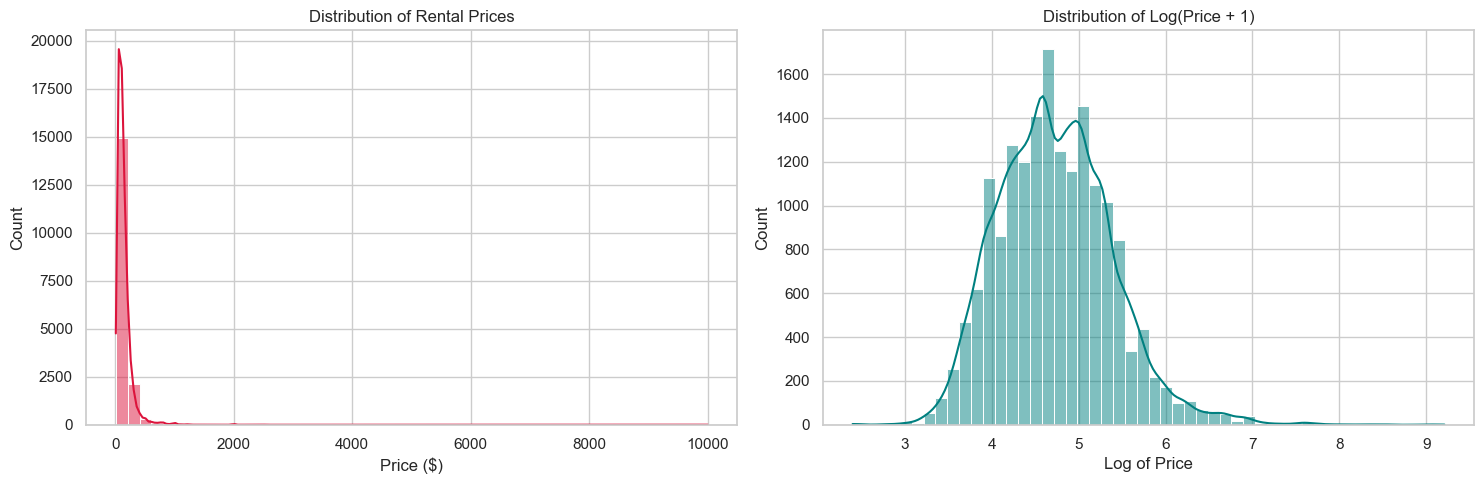

In [27]:
# Target Variable Distribution (Price)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Original Price Distribution
sns.histplot(df['price'], bins=50, kde=True, ax=axes[0], color='crimson')
axes[0].set_title('Distribution of Rental Prices')
axes[0].set_xlabel('Price ($)')

# Log-transformed Price Distribution (Per Cheat Sheet suggestion for highly skewed data)
sns.histplot(np.log1p(df['price']), bins=50, kde=True, ax=axes[1], color='teal')
axes[1].set_title('Distribution of Log(Price + 1)')
axes[1].set_xlabel('Log of Price')

plt.tight_layout()
plt.show()

C:\Users\wiona\AppData\Local\Temp\ipykernel_6940\2888781342.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='room_type', order=df['room_type'].value_index if hasattr(df['room_type'], 'value_index') else df['room_type'].value_counts().index, palette='viridis')


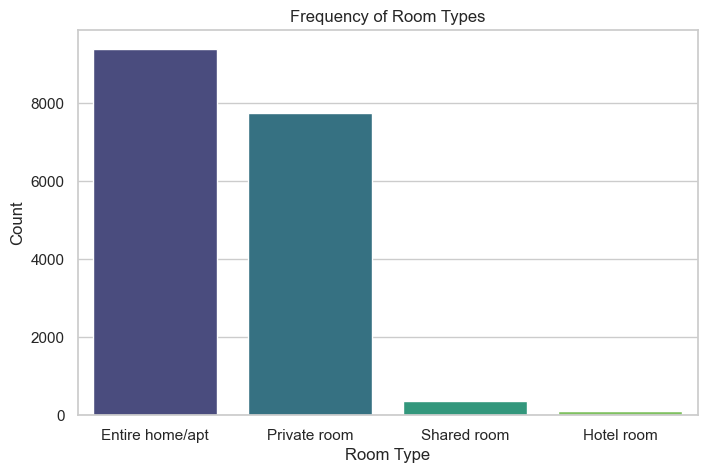

In [28]:
# Categorical Value Profiling (Room Types)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='room_type', order=df['room_type'].value_index if hasattr(df['room_type'], 'value_index') else df['room_type'].value_counts().index, palette='viridis')
plt.title('Frequency of Room Types')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.show()

C:\Users\wiona\AppData\Local\Temp\ipykernel_6940\4209647706.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='room_type', y='price', palette='Set2')


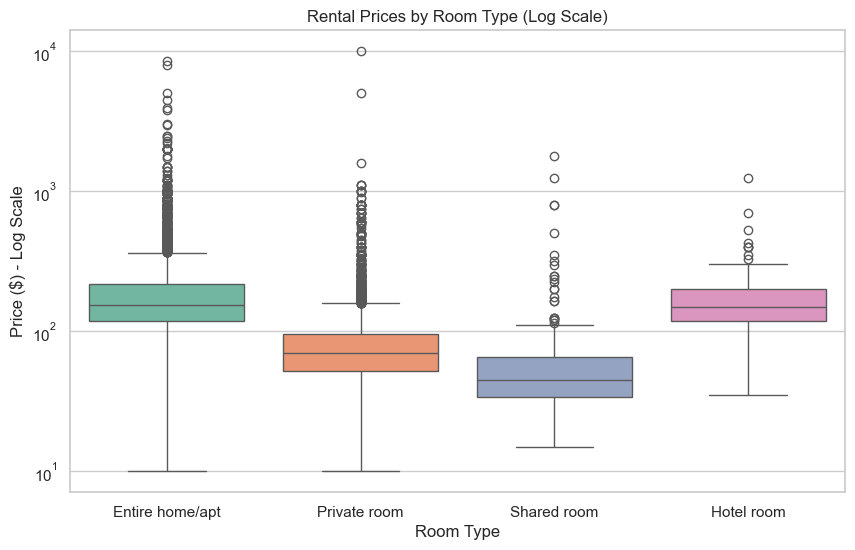

In [29]:
#Categorical x Continuous (Room Type vs Price)
plt.figure(figsize=(10, 6))
# Using a log scale on y-axis helps visualize the boxes if prices have extreme outliers
sns.boxplot(data=df, x='room_type', y='price', palette='Set2')
plt.yscale('log') 
plt.title('Rental Prices by Room Type (Log Scale)')
plt.xlabel('Room Type')
plt.ylabel('Price ($) - Log Scale')
plt.show()

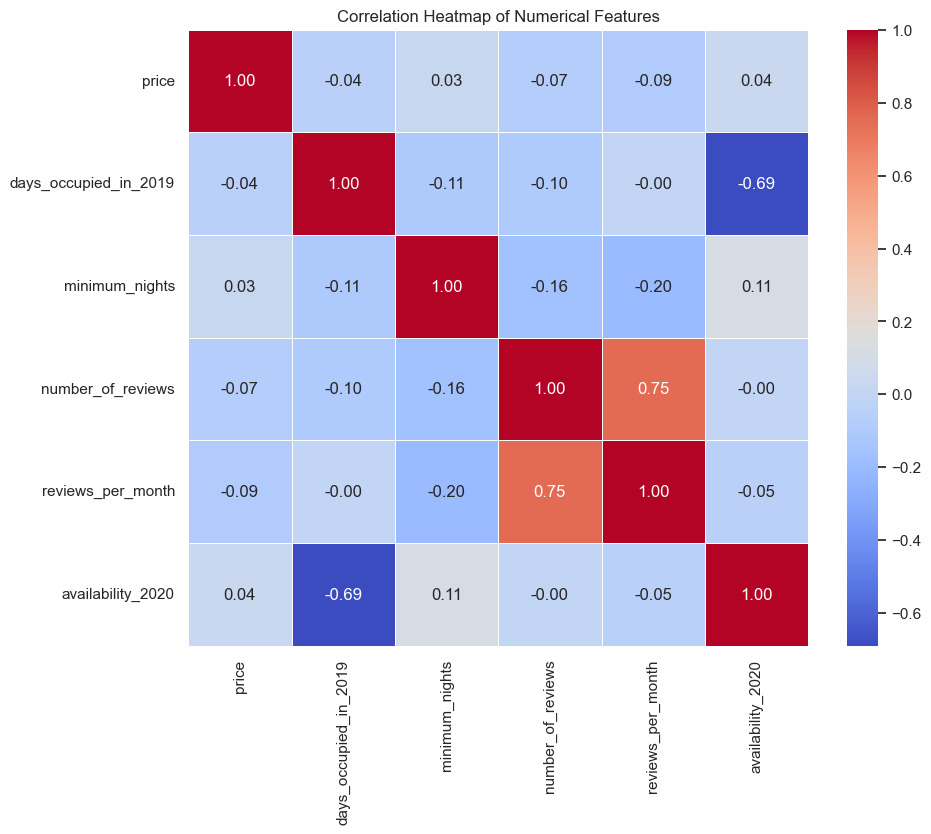

In [30]:
# Continuous x Continuous Relationships & Correlation Matrix
# Let's see how numerical fields correlate with each other
plt.figure(figsize=(10, 8))
numerical_cols = ['price', 'days_occupied_in_2019', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_2020']
corr_matrix = df[numerical_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

C:\Users\wiona\AppData\Local\Temp\ipykernel_6940\485399438.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_neighborhoods.values, y=top_neighborhoods.index, palette='magma')


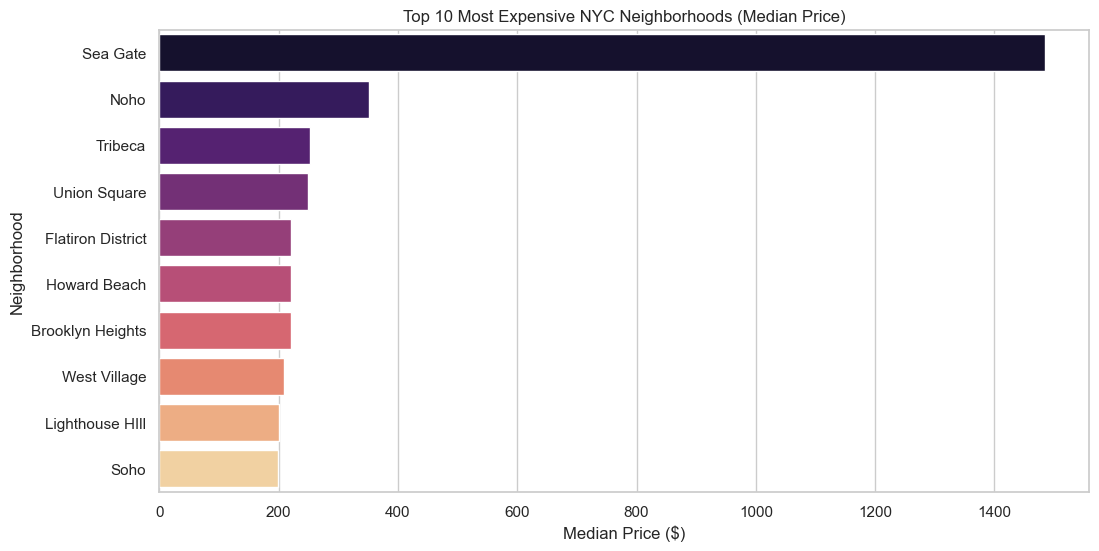

In [31]:
#Top 10 Most Expensive Neighborhoods (Median Price)
top_neighborhoods = df.groupby('neighbourhood')['price'].median().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_neighborhoods.values, y=top_neighborhoods.index, palette='magma')
plt.title('Top 10 Most Expensive NYC Neighborhoods (Median Price)')
plt.xlabel('Median Price ($)')
plt.ylabel('Neighborhood')
plt.show()

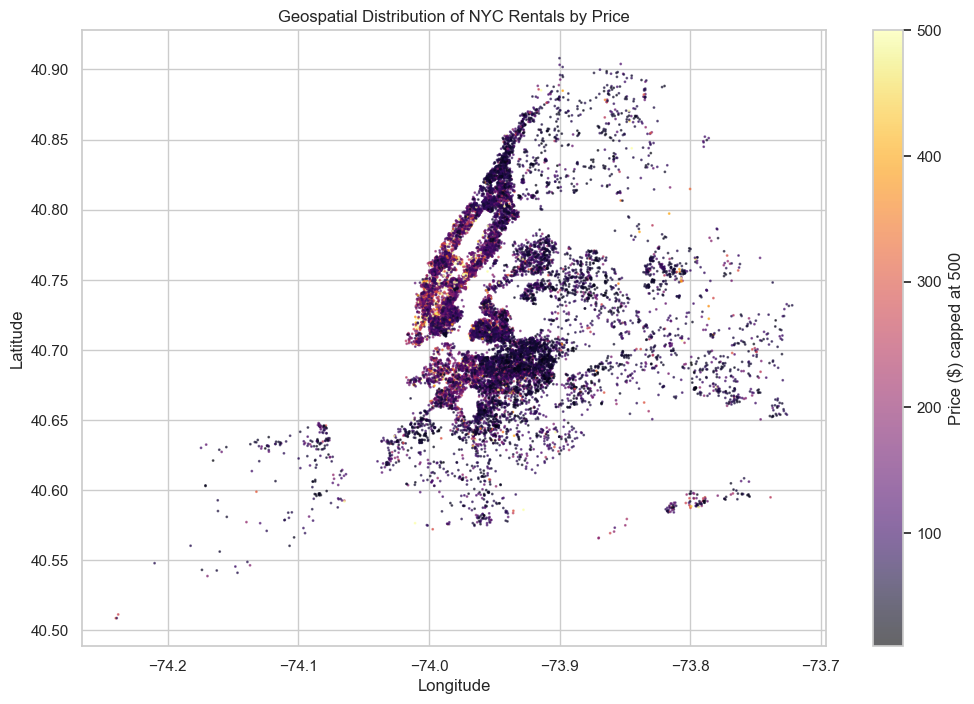

In [33]:
# Geospatial Scatter Plot (Latitude vs Longitude colored by Price)
plt.figure(figsize=(12, 8))

scatter = plt.scatter(df['longitude'], df['latitude'], c=df['price'], cmap='inferno', s=1, alpha=0.6, vmax=500)

plt.colorbar(scatter, label='Price ($) capped at 500')
plt.title('Geospatial Distribution of NYC Rentals by Price')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [35]:
### Hypothesis Testing

#### Theme 1: Room Type vs. Price
####* **H0:** There is no difference in the median rental price between "Entire home/apt" and "Private room".
####* **Ha:** "Entire home/apt" listings have a significantly higher median price than "Private room".
####* **Method:** Mann-Whitney U test (chosen due to skewed price distribution).

#### Theme 2: Activity vs. Price
####* **H0:** There is no correlation between a listing's popularity (`number_of_reviews`) and its `price`.
####* **Ha:** There is a significant correlation between popularity and price.
####* **Method:** Spearman's rank correlation.

In [36]:
from scipy import stats

# Split data by room type
entire_home = df[df['room_type'] == 'Entire home/apt']['price']
private_room = df[df['room_type'] == 'Private room']['price']

print(f"Entire home/apt count: {len(entire_home)}, Median: ${entire_home.median():.2f}")
print(f"Private room count: {len(private_room)}, Median: ${private_room.median():.2f}")

# Run Mann-Whitney U test
stat, p_value = stats.mannwhitneyu(entire_home, private_room, alternative='greater')

print("\n--- Mann-Whitney U Test Results ---")
print(f"U-statistic: {stat}")
print(f"p-value: {p_value}")

# Check significance
alpha = 0.05
if p_value < alpha:
    print(f"\nResult: Reject H0 (p < {alpha}). 'Entire home/apt' has a significantly higher median price.")
else:
    print(f"\nResult: Fail to reject H0 (p >= {alpha}). No significant difference in median prices.")

Entire home/apt count: 9404, Median: $154.00
Private room count: 7748, Median: $70.00

--- Mann-Whitney U Test Results ---
U-statistic: 65255037.0
p-value: 0.0

Result: Reject H0 (p < 0.05). 'Entire home/apt' has a significantly higher median price.


In [37]:
# Run Spearman correlation
corr_coef, p_value_corr = stats.spearmanr(df['number_of_reviews'], df['price'])

print("\n--- Spearman Rank Correlation Results ---")
print(f"Correlation coefficient (rho): {corr_coef:.4f}")
print(f"p-value: {p_value_corr}")

# Check significance
alpha = 0.05
if p_value_corr < alpha:
    print(f"\nResult: Reject H0 (p < {alpha}). Significant correlation found.")
    if corr_coef < 0:
        print(f"Interpretation: Negative correlation ({corr_coef:.4f}). Cheaper listings tend to have more reviews.")
    else:
        print(f"Interpretation: Positive correlation ({corr_coef:.4f}). Pricier listings tend to have more reviews.")
else:
    print(f"\nResult: Fail to reject H0 (p >= {alpha}). No significant correlation between price and reviews.")


--- Spearman Rank Correlation Results ---
Correlation coefficient (rho): -0.0693
p-value: 3.2056883203422645e-20

Result: Reject H0 (p < 0.05). Significant correlation found.
Interpretation: Negative correlation (-0.0693). Cheaper listings tend to have more reviews.


In [38]:
###Interpretation of Results

#### Theme 1: Room Type vs. Price
###* **Finding:** The Mann-Whitney U test confirms that "Entire home/apt" listings (Median: $154.00) have a significantly higher rental price than "Private room" listings (Median: $70.00) with a p-value of 0.0.
###* **Conclusion:** Room type is a critical feature explaining price variation. The premium for renting an entire space instead of a single room is statistically robust.

#### Theme 2: Activity vs. Price
###* **Finding:** The Spearman rank correlation shows a statistically significant, very weak negative correlation ($\rho = -0.0693$, p-value $\approx 0$). 
###* **Conclusion:** While the relationship is weak, the negative direction implies that cheaper listings tend to accumulate more reviews. This could be driven by higher occupancy and turnover rates for budget-friendly accommodations.

In [ ]:
### 7. Feature Engineering Strategy

Based on the EDA findings, the following preprocessing steps will be applied to prepare the dataset for predictive modeling:

###1. **Log Transformation:** The target variable `price` is heavily right-skewed. Taking the log transform ($\log(x + 1)$) will normalize its distribution for regression models.
###2. **Categorical Encoding:** High-impact categorical variables like `room_type` and `neighbourhood` will be one-hot encoded.
###3. **Feature Dropping:** Structural columns like `id` will be omitted as they carry no predictive power.

In [39]:
# Create a copy of the dataframe for engineering
df_engineered = df.copy()

# 1. Log transform the skewed target variable
df_engineered['log_price'] = np.log1p(df_engineered['price'])

# 2. Drop unique identifier column
df_engineered = df_engineered.drop(columns=['id'])

# Preview the prepared dataset
print(f"Engineered Dataset Shape: {df_engineered.shape}")
df_engineered[['price', 'log_price']].head()

Engineered Dataset Shape: (17607, 11)


,price,log_price
0,225,5.420535
1,89,4.499810
2,200,5.303305
3,60,4.110874
4,79,4.382027


In [1]:
## Preprocessing and Training Data Development

##  In this section, we prepare the dataset for machine learning models by encoding categorical variables, standardizing numeric feature scales, and splitting the data into training and testing sets.

In [8]:

import pandas as pd
import numpy as np


df = pd.read_csv('NYC_Rental_Cleaned.csv')


print(f"Dataset successfully loaded. Shape: {df.shape}")

Dataset successfully loaded. Shape: (17607, 11)


In [9]:

df_engineered = df.copy()


df_engineered['log_price'] = np.log1p(df_engineered['price'])


df_engineered = df_engineered.drop(columns=['id', 'latitude', 'longitude'])

print(f"Engineered Dataset Shape: {df_engineered.shape}")

Engineered Dataset Shape: (17607, 9)


In [10]:
# Select features (X) and target (y)
# We use log_price as target since price was heavily skewed
y = df_engineered['log_price']
X = df_engineered.drop(columns=['price', 'log_price'])

# Create dummy variables for categorical features (room_type, neighbourhood)
X_encoded = pd.get_dummies(X, columns=['room_type', 'neighbourhood'], drop_first=True)

print(f"Original features shape: {X.shape}")
print(f"Encoded features shape: {X_encoded.shape}")
X_encoded.head()

Original features shape: (17607, 7)
Encoded features shape: (17607, 193)


,days_occupied_in_2019,minimum_nights,number_of_reviews,reviews_per_month,availability_2020,room_type_Hotel room,room_type_Private room,room_type_Shared room,neighbourhood_Alphabet City,neighbourhood_Annadale,...,neighbourhood_West Village,neighbourhood_Westchester Village,neighbourhood_Westerleigh,neighbourhood_Whitestone,neighbourhood_Williamsbridge,neighbourhood_Williamsburg,neighbourhood_Windsor Terrace,neighbourhood_Woodhaven,neighbourhood_Woodlawn,neighbourhood_Woodside
0,15,10,48,0.39,1,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,188,1,295,4.67,1,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,362,3,78,0.60,19,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0,29,49,0.38,365,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,141,2,454,3.52,242,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [12]:
###Train-Test Split

## We split the encoded features (`X_encoded`) and target (`y`) into training (80%) and testing (20%) datasets.

In [13]:
from sklearn.model_selection import train_test_split

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (14085, 193), y_train shape: (14085,)
X_test shape: (3522, 193), y_test shape: (3522,)


In [14]:
### Feature Scaling

###We apply `StandardScaler` to the continuous numeric columns to normalize their magnitudes. The scaler is fit only on the training set to prevent data leakage.

In [15]:
from sklearn.preprocessing import StandardScaler

# Define continuous numeric columns to be scaled
numeric_cols = ['days_occupied_in_2019', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_2020']

# Initialize scaler
scaler = StandardScaler()

# Create copies to avoid slicing warnings
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit on training data and transform both sets
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Preview the scaled columns
X_train_scaled[numeric_cols].head()

,days_occupied_in_2019,minimum_nights,number_of_reviews,reviews_per_month,availability_2020
6491,-1.039041,-0.170927,0.681675,0.503103,1.364230
2453,-0.563000,-0.269861,0.849207,0.325598,0.965826
218,0.987972,-0.220394,0.377072,-0.102862,-0.606062
8439,0.749951,1.065749,-0.780422,-0.916937,-0.482918
4618,-1.115822,-0.220394,2.387456,1.243728,1.219356


In [16]:
# Optional: Save processed datasets for the next modeling step
X_train_scaled.to_csv('X_train_preprocessed.csv', index=False)
X_test_scaled.to_csv('X_test_preprocessed.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
print("Preprocessed datasets successfully saved as CSV!")

Preprocessed datasets successfully saved as CSV!
